# 03 -- Statistical Benchmarking & Outlier Analysis

Specialty-adjusted peer benchmarking and responsible outlier detection, against the real `gold_provider_benchmark` / `gold_provider_outlier` tables (6.7M provider-years, min peer-group size 30 -- see `sql/gold/06_gold_provider_benchmark.sql`).

> **Statistical outliers represent unusual utilization or cost patterns relative to peer providers and do not by themselves indicate fraud, waste, abuse, or improper billing.**

In [1]:
import sys
sys.path.insert(0, "../src")
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
con = duckdb.connect("../data/cms_medicare.duckdb", read_only=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## Benchmark coverage

In [2]:
con.execute("""
SELECT benchmark_reliable, COUNT(*) AS n,
       ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (), 2) AS pct
FROM gold_provider_benchmark GROUP BY 1
""").fetchdf()

,benchmark_reliable,n,pct
0,False,445,0.01
1,True,6687176,99.99


## Percentile rank distribution (payment per beneficiary)

By construction this should be roughly uniform on [0,1] within each peer group -- a sanity check on the `PERCENT_RANK()` computation.

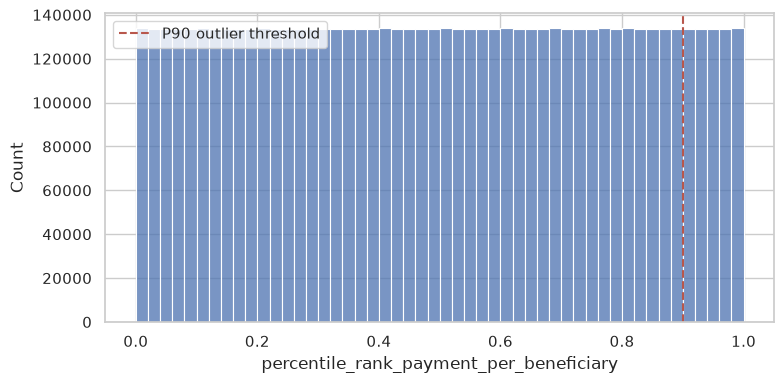

In [3]:
df = con.execute("""
SELECT percentile_rank_payment_per_beneficiary FROM gold_provider_benchmark
WHERE benchmark_reliable
""").fetchdf()
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(df["percentile_rank_payment_per_beneficiary"], bins=50, ax=ax)
ax.axvline(0.90, color="#B8574C", linestyle="--", label="P90 outlier threshold")
ax.legend(); plt.tight_layout(); plt.show()

## Robust z-score distribution (MAD-based)

Threshold at 3.5 (Iglewicz & Hoaglin, 1993) marks the robust-z outlier flag.

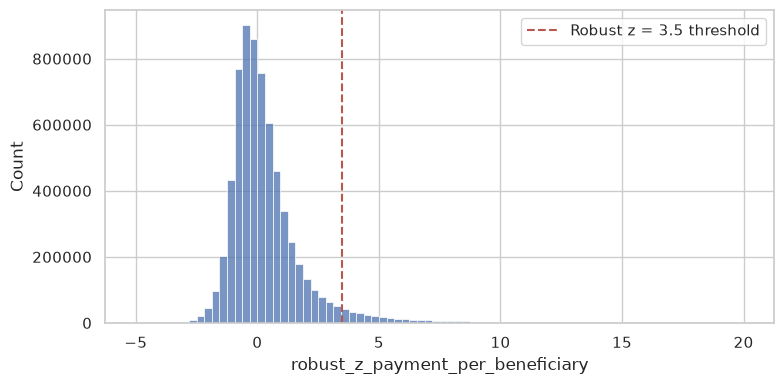

In [4]:
df = con.execute("""
SELECT robust_z_payment_per_beneficiary FROM gold_provider_benchmark
WHERE benchmark_reliable AND robust_z_payment_per_beneficiary IS NOT NULL
  AND robust_z_payment_per_beneficiary BETWEEN -5 AND 20
""").fetchdf()
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(df["robust_z_payment_per_beneficiary"], bins=80, ax=ax)
ax.axvline(3.5, color="#B8574C", linestyle="--", label="Robust z = 3.5 threshold")
ax.legend(); plt.tight_layout(); plt.show()

## Peer comparison: payment per beneficiary by specialty (top 10 by volume)

This is exactly why benchmarking must be specialty-adjusted -- medians and spreads differ by an order of magnitude across specialties.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

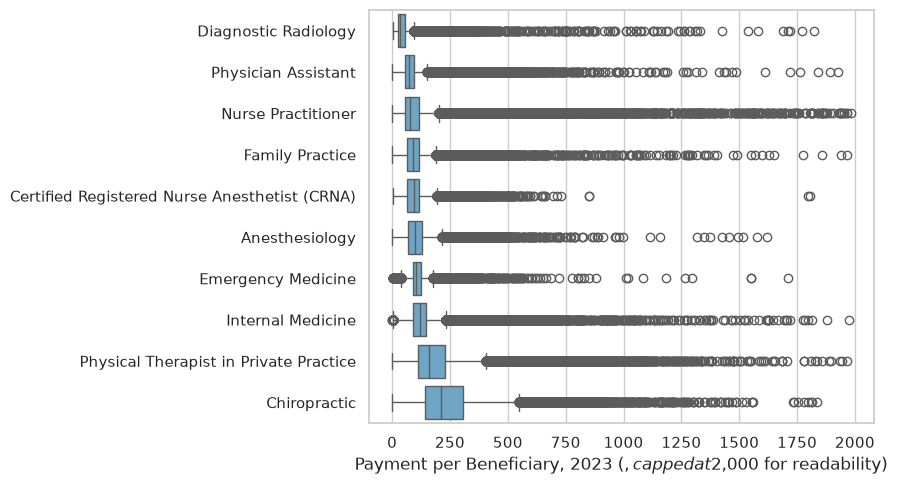

In [5]:
top_specs = con.execute("""
    SELECT provider_specialty FROM gold_specialty_year WHERE source_year=2023
    ORDER BY provider_count DESC LIMIT 10
""").fetchdf()["provider_specialty"].tolist()
df = con.execute(f"""
    SELECT provider_specialty, payment_per_beneficiary FROM gold_provider_year
    WHERE source_year = 2023 AND provider_specialty IN {tuple(top_specs)}
      AND payment_per_beneficiary BETWEEN 0 AND 2000
""").fetchdf()
fig, ax = plt.subplots(figsize=(9,5))
order = df.groupby("provider_specialty")["payment_per_beneficiary"].median().sort_values().index
sns.boxplot(df, y="provider_specialty", x="payment_per_beneficiary", order=order, ax=ax, color="#5FA8D3")
ax.set_xlabel("Payment per Beneficiary, 2023 ($, capped at $2,000 for readability)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## Outlier flags: method agreement

How many of the three methods (percentile / IQR / robust z) agree per flagged provider-year -- a robust multi-method signal vs. a single-
method edge case.

In [6]:
con.execute("""
SELECT methods_triggered_count, COUNT(*) AS n
FROM gold_provider_outlier GROUP BY 1 ORDER BY 1
""").fetchdf()

,methods_triggered_count,n
0,1,293659
1,2,93617
2,3,300833
